BUSINESS OBJECTIVE

This notebook focuses on predicting potential RFC (Request for Change) failures and operational risk indicators using machine learning.

RFC risk prediction helps organizations:

- identify unstable operational changes
- reduce service disruption risks
- improve ITSM reliability
- support proactive operational monitoring
- improve change management processes

In [ ]:
IMPORT LIBRARIES

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix

)

from sklearn.model_selection import cross_val_score

import joblib

LOAD CLEAN DATASET

In [43]:
df = pd.read_csv(
    r"C:\Projects_Dm\ITSM_project\data\processed\itsm_cleaned.csv",
    low_memory=False
)
print(df.shape)

df.head()

(45226, 26)


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,Open_Year,Open_Month,Open_Day,Open_Hour,Open_Weekday
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,2013-11-04 13:51:00,3.871691e+09,Other,1.0,SD0000007,2012,2,5,13,6
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,2013-12-02 12:36:00,4.354786e+09,Software,1.0,SD0000011,2012,3,12,15,0
2,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,2013-11-14 09:31:00,4.321833e+09,Operator error,1.0,SD0000025,2012,7,17,11,1
3,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,2013-11-08 13:55:00,3.383903e+09,Other,1.0,SD0000029,2012,8,10,11,4
4,WBA000124,application,Web Based Application,WBS000088,IM0000013,Closed,4,4,4.0,0.006676,...,2013-11-08 13:54:00,3.383437e+09,Other,1.0,SD0000031,2012,8,10,11,4


In [44]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Resolved_Time',
       'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction', 'Open_Year',
       'Open_Month', 'Open_Day', 'Open_Hour', 'Open_Weekday'],
      dtype='str')

CREATE RFC RISK TARGET

In [45]:
df['RFC_Risk'] = np.where(

    (

        (df['Priority'] >= 4)

        |

        (df['No_of_Reassignments'] >= 3)

        |

        (df['Handle_Time_hrs'] >= df['Handle_Time_hrs'].median())

    ),

    1,

    0
)

In [46]:
df['RFC_Risk']

0        1
1        1
2        1
3        1
4        1
        ..
45221    1
45222    1
45223    1
45224    1
45225    0
Name: RFC_Risk, Length: 45226, dtype: int64

In [47]:
df.drop(

    columns=[

        'Priority',

        'No_of_Reassignments',

        'Handle_Time_hrs'

    ],

    inplace=True,

    errors='ignore'
)

In [39]:
drop_cols = [

    'Incident_ID',

    'KB_number',

    'Related_Interaction',

    'WBS',

    'Open_Time',

    'Resolved_Time',

    'Close_Time'

]

df.drop(
    columns=drop_cols,
    inplace=True,
    errors='ignore'
)

ENCODE CATEGORICAL FEATURES

In [48]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = df.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = le

C:\Users\nutha\AppData\Local\Temp\ipykernel_8608\1305863929.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


FEATURES & TARGET

In [49]:
X = df.drop('RFC_Risk', axis=1)

y = df['RFC_Risk']

TRAIN TEST SPLIT

In [50]:
df.drop(

    columns=[

        'Priority',

        'No_of_Reassignments',

        'Handle_Time_hrs'

    ],

    inplace=True,

    errors='ignore'
)

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

RANDOM FOREST

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=20,

    class_weight='balanced',

    random_state=42

)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

XGBOOST

In [53]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    eval_metric='logloss',

    random_state=42

)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

EVALUATION

In [54]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model_name, y_test, y_pred):

    print(f"\n{'='*50}")

    print(model_name)

    print(f"{'='*50}")

    print("\nAccuracy Score:\n")

    print(
        accuracy_score(y_test, y_pred)
    )

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

In [55]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)


Random Forest

Accuracy Score:

0.9571081140835729

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.87      0.75       673
           1       0.99      0.96      0.98      8373

    accuracy                           0.96      9046
   macro avg       0.82      0.92      0.86      9046
weighted avg       0.97      0.96      0.96      9046


XGBoost

Accuracy Score:

0.9594295821357506

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.76      0.74       673
           1       0.98      0.98      0.98      8373

    accuracy                           0.96      9046
   macro avg       0.85      0.87      0.86      9046
weighted avg       0.96      0.96      0.96      9046



CROSS VALIDATION

In [56]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    xgb_model,

    X,

    y,

    cv=5,

    scoring='accuracy'

)

print(cv_scores)

print("\nAverage Accuracy:\n")

print(cv_scores.mean())

[0.92748176 0.94173577 0.93377557 0.9355445  0.93808734]

Average Accuracy:

0.9353249865835291


FEATURE IMPORTANCE

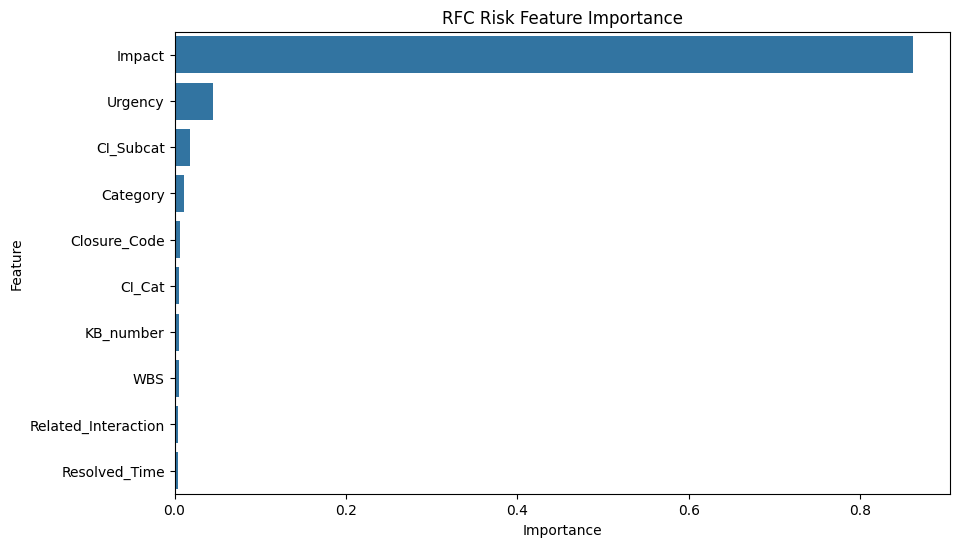

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("RFC Risk Feature Importance")

plt.show()

SAVE MODEL

In [59]:
import joblib

joblib.dump(

    xgb_model,

    r"C:\Projects_Dm\ITSM_project\models\rfc_risk_model.pkl"

)

print("RFC Risk model saved successfully")

RFC Risk model saved successfully
